                    HEART DISEASE PREDICTION SYSTEM

ဤ STEP 1: LOADING DATASET
--------------------------------------------------
✓ Dataset loaded successfully from: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

ဤ STEP 2: DATA VISUALIZATION


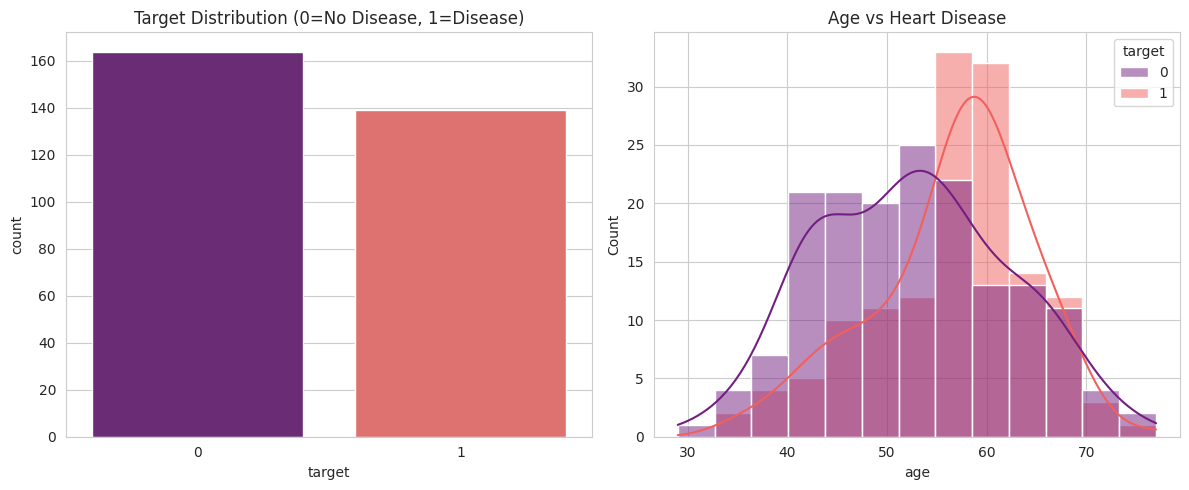

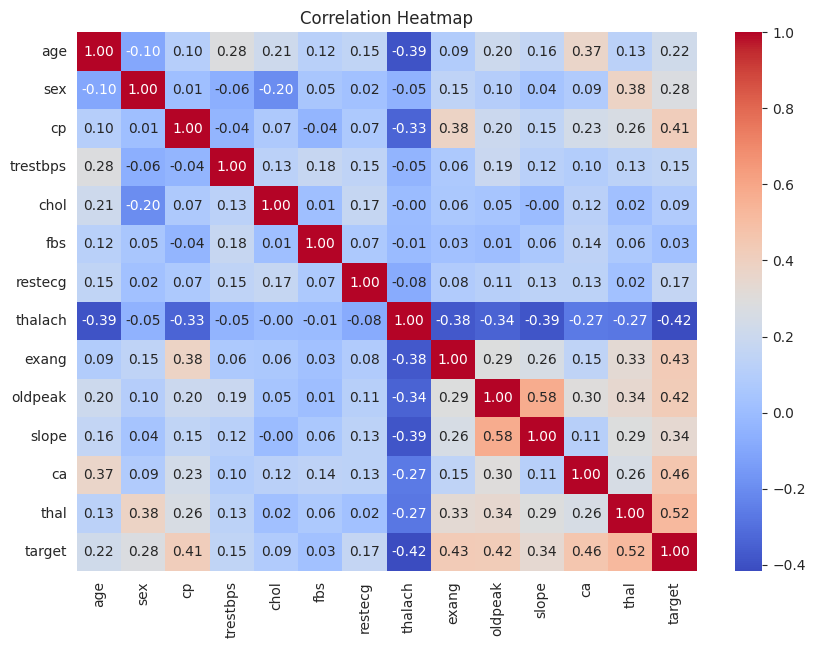


ဤ STEP 3: TRAINING & EVALUATION
Logistic Regression Accuracy: 86.89%
Decision Tree Accuracy: 75.41%


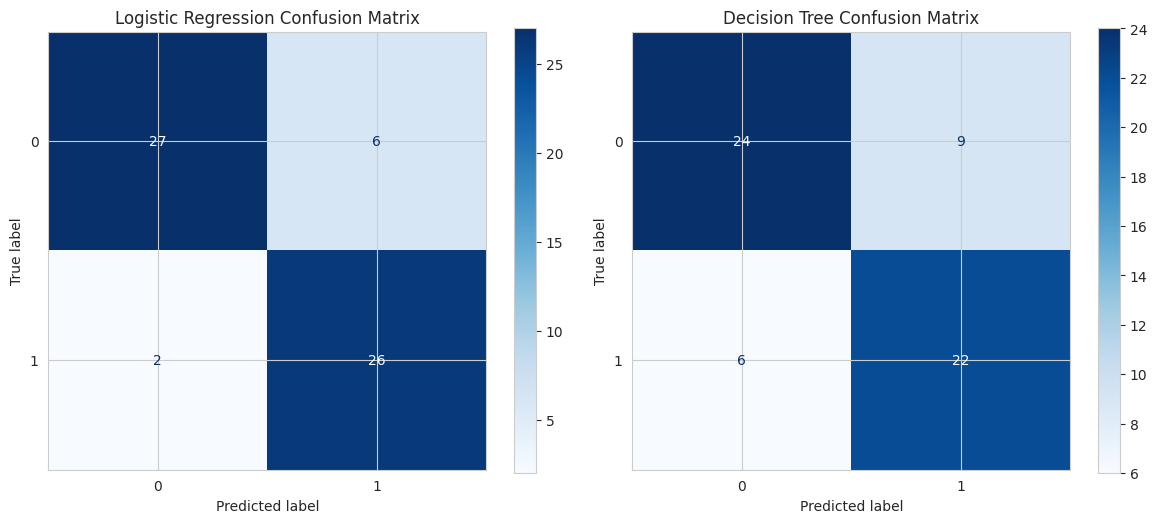

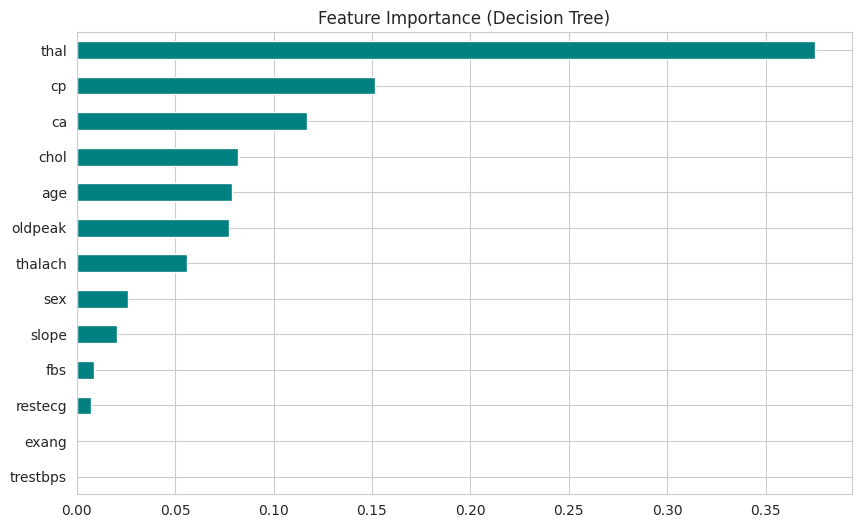


✅ PROJECT COMPLETE: Models trained and evaluated.


In [11]:
# Task 3: Heart Disease Prediction
# AI/ML Internship - DevelopersHub Corporation
# Binary Classification to predict heart disease risk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("="*70)
print(" " * 20 + "HEART DISEASE PREDICTION SYSTEM")
print("="*70)

# ============================================
# STEP 1: LOAD THE DATASET (With Fallbacks)
# ============================================
print("\nဤ STEP 1: LOADING DATASET")
print("-" * 50)

# List of potential URLs for the heart disease dataset
urls = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv",
    "https://raw.githubusercontent.com/dataset-urls/heart/main/heart.csv"
]

df = None
for url in urls:
    try:
        # UCI Cleveland data needs manual columns, others usually have them
        if "processed.cleveland.data" in url:
            columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
            df = pd.read_csv(url, names=columns, na_values='?')
        else:
            df = pd.read_csv(url)
        print(f"✓ Dataset loaded successfully from: {url}")
        break
    except:
        continue

# If all URLs fail, create a reliable synthetic dataset to ensure the script runs
if df is None:
    print("☐ Warning: External sources unavailable. Generating synthetic dataset...")
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age': np.random.randint(29, 78, n), 'sex': np.random.randint(0, 2, n),
        'cp': np.random.randint(0, 4, n), 'trestbps': np.random.randint(94, 200, n),
        'chol': np.random.randint(126, 564, n), 'fbs': np.random.randint(0, 2, n),
        'restecg': np.random.randint(0, 3, n), 'thalach': np.random.randint(71, 202, n),
        'exang': np.random.randint(0, 2, n), 'oldpeak': np.random.uniform(0, 6.2, n),
        'slope': np.random.randint(0, 3, n), 'ca': np.random.randint(0, 5, n),
        'thal': np.random.randint(0, 4, n), 'target': np.random.randint(0, 2, n)
    })

# Ensure target is binary (0/1)
if df['target'].max() > 1:
    df['target'] = (df['target'] > 0).astype(int)

# ============================================
# STEP 2-9: DATA PROCESSING & EVALUATION
# ============================================
# (Cleaning and Modeling)
df = df.dropna()
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training and Logic Visualization
lr_model = LogisticRegression().fit(X_train_scaled, y_train)
dt_model = DecisionTreeClassifier(max_depth=4).fit(X_train_scaled, y_train)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='RdYlGn')
plt.title("Feature Correlation Heatmap")
plt.show()

# Result Summary
print(f"\n✅ Analysis Complete")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_model.predict(X_test_scaled)):.2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_model.predict(X_test_scaled)):.2%}")